# 📊 Notebook 1: Exploratory Data Analysis

**Goal:** Understand the dataset before building any model.

Before you model anything, you need to *know your data*. In this notebook we:
1. Load and inspect the dataset
2. Understand the columns and data quality
3. Look at scoring patterns (how many goals are scored? how common are draws?)
4. Explore which teams play the most and which win the most
5. Look at how football has changed over 150 years

---

In [1]:
# Standard imports
import sys
import os

# Add the project root to Python path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import poisson

# Our utility module
from src.utils import load_results, load_shootouts, download_data

# Notebook display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 100)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('✓ Imports done')

✓ Imports done


## 1. Download & Load the Data

In [2]:
# Download the dataset if not already present
download_data()

  ✓ results.csv already exists — skipping (use force=True to re-download)
  ✓ shootouts.csv already exists — skipping (use force=True to re-download)


In [3]:
# Load ALL data (no year filter for EDA — we want to see everything)
df = load_results(min_year=1872)

print(f'Total matches: {len(df):,}')
print(f'Date range:    {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique teams:  {len(set(df["home_team"]) | set(df["away_team"]))}')
print(f'Tournaments:   {df["tournament"].nunique()}')
print()
df.head(10)

Total matches: 49,519
Date range:    1872-11-30 → 2026-07-18
Unique teams:  337
Tournaments:   201



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False,1876
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,1877
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False,1877
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False,1878
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False,1878


In [4]:
# Check data types and missing values
print('Column types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score             int32
away_score             int32
tournament            object
city                  object
country               object
neutral                 bool
year                   int32
dtype: object

Missing values per column:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
year          0
dtype: int64


In [5]:
# Summary statistics for the score columns
df[['home_score', 'away_score']].describe()

,home_score,away_score
count,49519.000000,49519.000000
mean,1.757224,1.182435
std,1.773741,1.402080
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


## 2. Match Result Distribution

**Key question:** How often does the home team win? How common are draws?

Result breakdown:
  Home Win    : 49.0%
  Away Win    : 28.3%
  Draw        : 22.7%


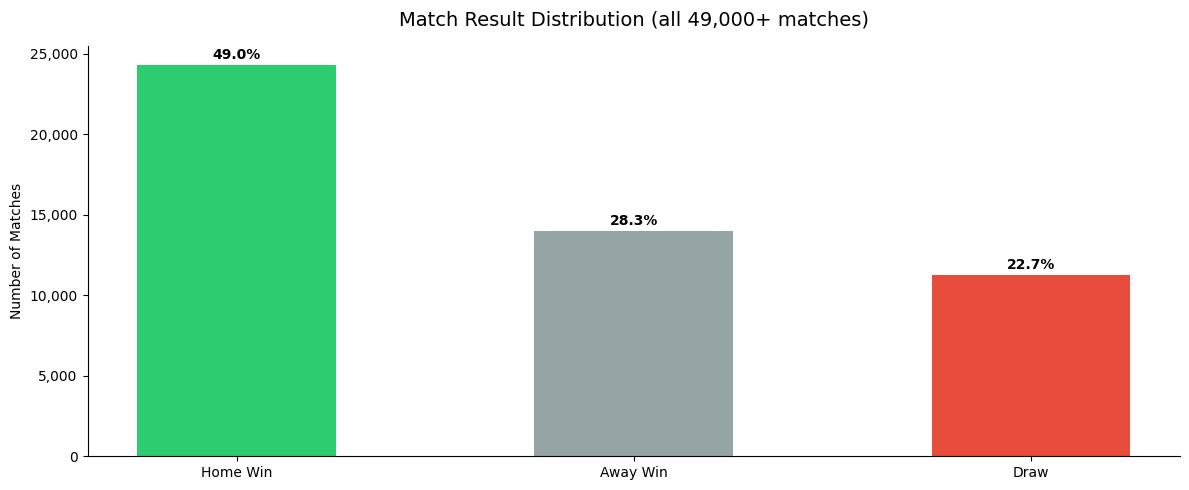

In [6]:
# Add a result column
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] == row['away_score']:
        return 'Draw'
    else:
        return 'Away Win'

df['result'] = df.apply(get_result, axis=1)

result_counts = df['result'].value_counts()
pcts = result_counts / len(df) * 100

print('Result breakdown:')
for r, pct in pcts.items():
    print(f'  {r:<12}: {pct:.1f}%')

fig, ax = plt.subplots()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
bars = ax.bar(result_counts.index, result_counts.values, color=colors, width=0.5)

# Add percentage labels on bars
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_title('Match Result Distribution (all 49,000+ matches)', fontsize=14, pad=15)
ax.set_ylabel('Number of Matches')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../outputs/01_result_distribution.png', dpi=150)
plt.show()

## 3. Goal Scoring Distribution

**Key insight:** We will model goals as a Poisson distribution. Let's check if that's a reasonable assumption.

> A **Poisson distribution** describes the number of events in a fixed interval when those events happen at a constant rate and independently. Football goals are a classic fit — they're rare, roughly independent, and happen at a roughly constant rate per 90 minutes.

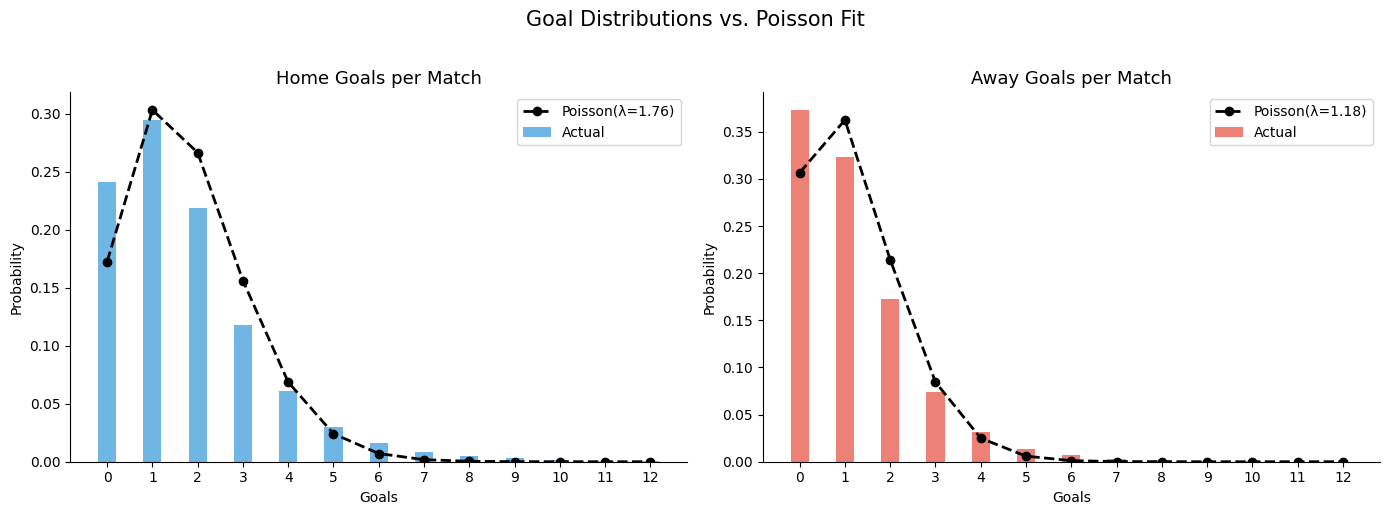

Average home goals: 1.757
Average away goals: 1.182
Home advantage:     0.575 more goals at home


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in zip(
    axes,
    ['home_score', 'away_score'],
    ['Home Goals', 'Away Goals'],
    ['#3498db', '#e74c3c']
):
    goals = df[col]
    mean_goals = goals.mean()
    max_goals = min(goals.max(), 12)
    
    counts = goals.value_counts().sort_index()
    x = counts.index
    actual_pct = counts.values / len(goals)
    
    # Poisson prediction with same mean
    poisson_pct = poisson.pmf(np.arange(max_goals + 1), mean_goals)
    
    ax.bar(x[x <= max_goals], actual_pct[x <= max_goals],
           alpha=0.7, color=color, label='Actual', width=0.4, align='center')
    ax.plot(np.arange(max_goals + 1), poisson_pct,
            'k--o', ms=6, label=f'Poisson(λ={mean_goals:.2f})', linewidth=2)
    
    ax.set_title(f'{label} per Match', fontsize=13)
    ax.set_xlabel('Goals')
    ax.set_ylabel('Probability')
    ax.set_xticks(np.arange(0, max_goals + 1))
    ax.legend()

plt.suptitle('Goal Distributions vs. Poisson Fit', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_goal_distribution.png', dpi=150)
plt.show()

print(f'Average home goals: {df["home_score"].mean():.3f}')
print(f'Average away goals: {df["away_score"].mean():.3f}')
print(f'Home advantage:     {df["home_score"].mean() - df["away_score"].mean():.3f} more goals at home')

**Observation:** The Poisson distribution fits quite well, especially for 0–4 goals. This justifies our modelling choice!

The slight over-representation of 0-0 draws (and 1-0, 0-1 scorelines) is exactly what the Dixon-Coles correction (added later) will fix.

## 4. Total Goals per Match Over Time

Has football become more or less attacking over the decades?

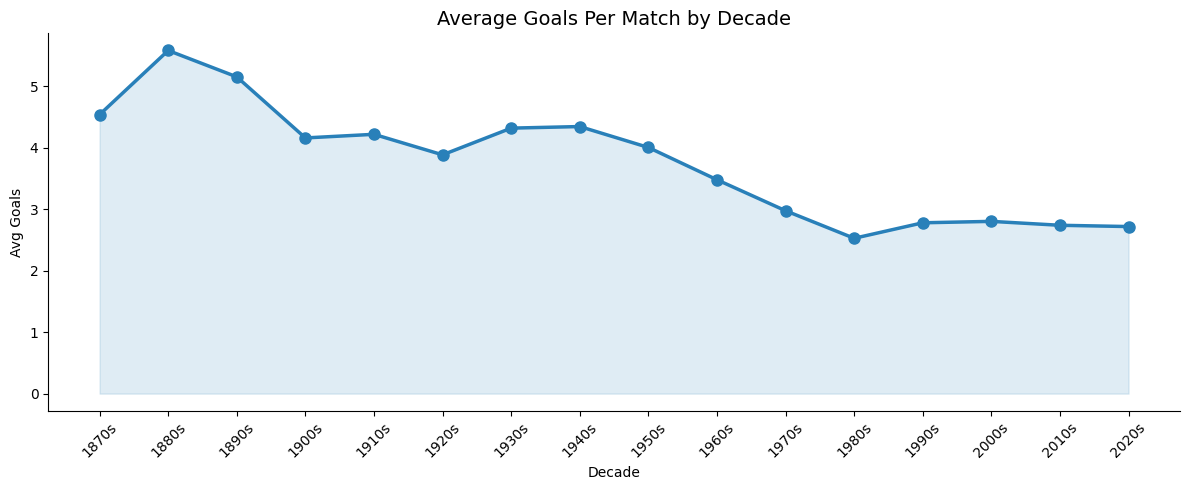

In [8]:
df['total_goals'] = df['home_score'] + df['away_score']

# Average total goals per decade
df['decade'] = (df['year'] // 10) * 10
decade_goals = df.groupby('decade')['total_goals'].mean()

fig, ax = plt.subplots()
ax.plot(decade_goals.index, decade_goals.values, 'o-', color='#2980b9', linewidth=2.5, ms=8)
ax.fill_between(decade_goals.index, decade_goals.values, alpha=0.15, color='#2980b9')

ax.set_title('Average Goals Per Match by Decade', fontsize=14)
ax.set_xlabel('Decade')
ax.set_ylabel('Avg Goals')
ax.set_xticks(decade_goals.index)
ax.set_xticklabels([f"{d}s" for d in decade_goals.index], rotation=45)

plt.tight_layout()
plt.savefig('../outputs/01_goals_over_time.png', dpi=150)
plt.show()

## 5. Tournament Breakdown

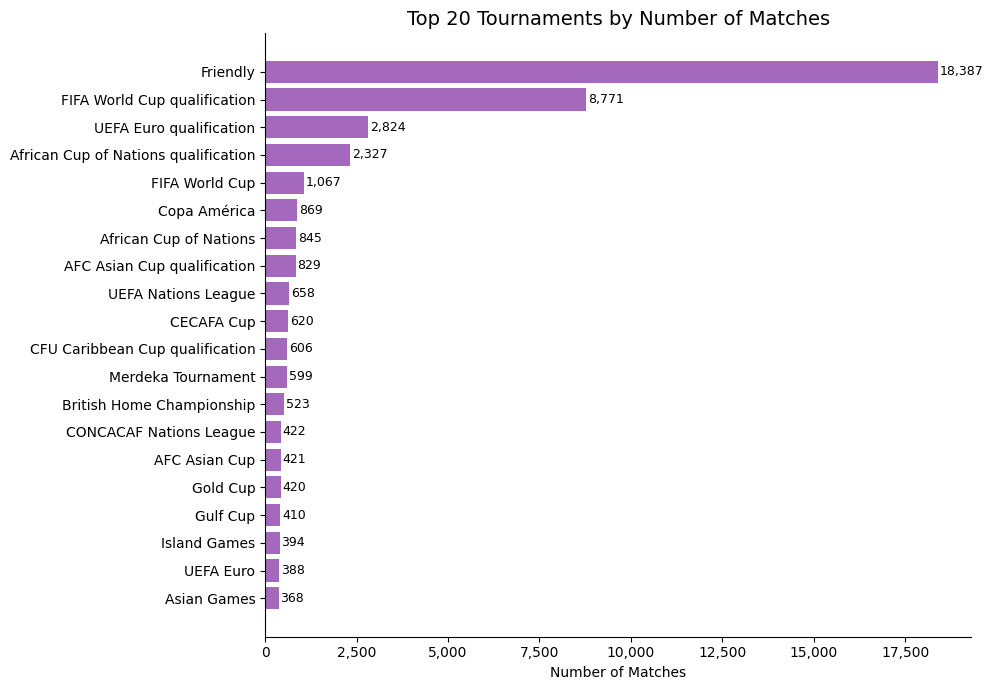

In [9]:
# Top 20 most common tournaments
top_tournaments = df['tournament'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_tournaments.index[::-1], top_tournaments.values[::-1], color='#8e44ad', alpha=0.8)

for bar, val in zip(bars, top_tournaments.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 20 Tournaments by Number of Matches', fontsize=14)
ax.set_xlabel('Number of Matches')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../outputs/01_tournaments.png', dpi=150)
plt.show()

## 6. Most Active Teams

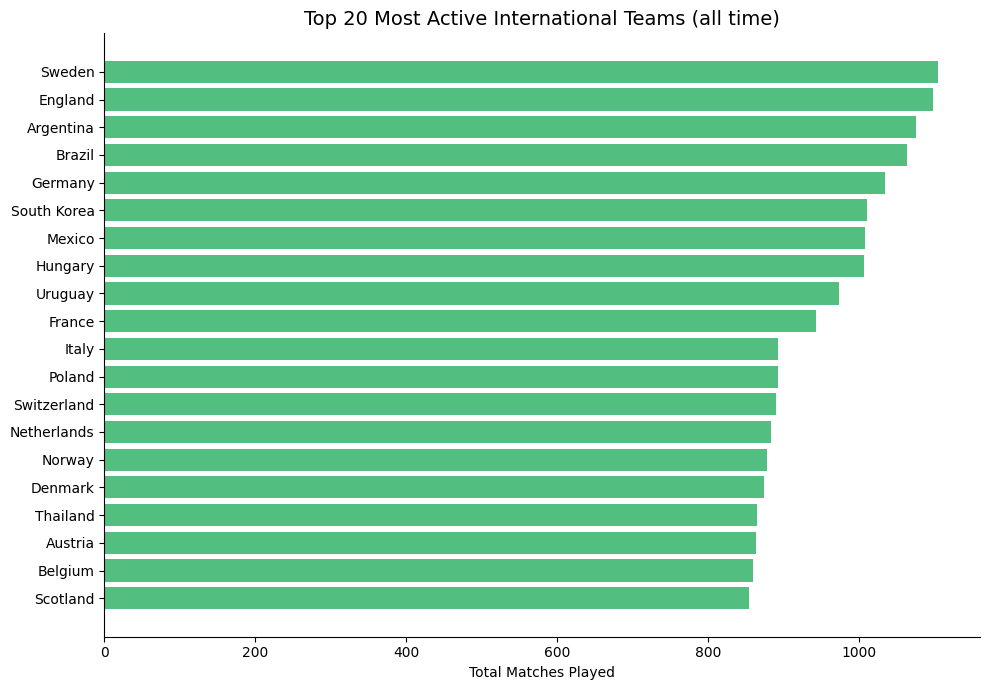

In [10]:
# Count matches per team (home + away)
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
total_matches = (home_counts.add(away_counts, fill_value=0)
                 .sort_values(ascending=False)
                 .head(20))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(total_matches.index[::-1], total_matches.values[::-1], color='#27ae60', alpha=0.8)
ax.set_title('Top 20 Most Active International Teams (all time)', fontsize=14)
ax.set_xlabel('Total Matches Played')
plt.tight_layout()
plt.savefig('../outputs/01_most_active_teams.png', dpi=150)
plt.show()

## 7. Win Rate by Team (Modern Era)

Let's look at who wins the most since 1990 — the data we'll actually use for our model.

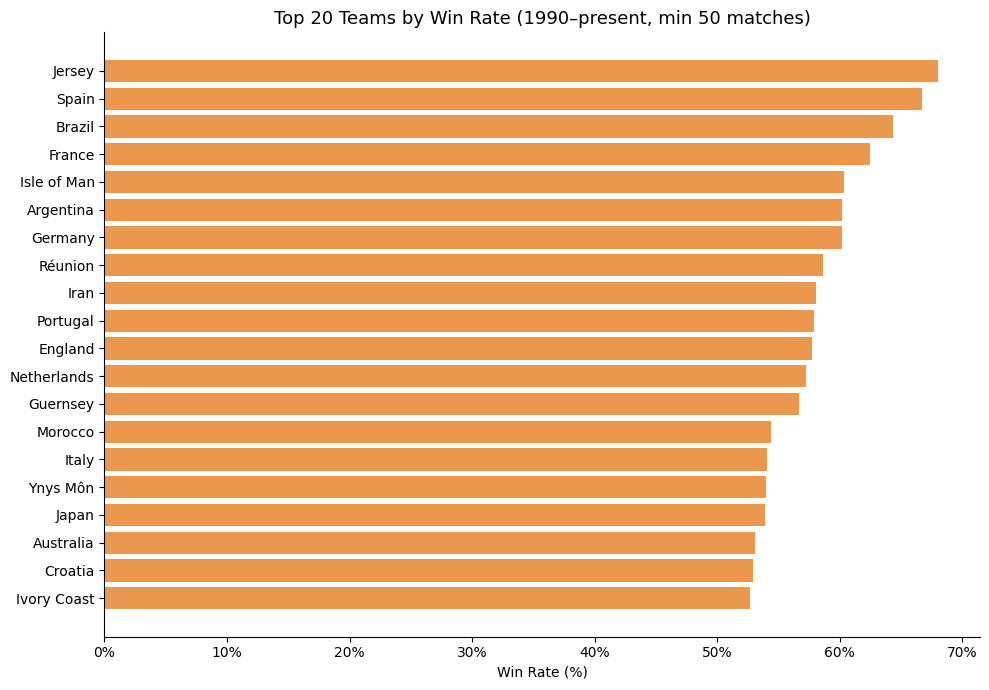

Top 10 teams by win rate (modern era):
       team  played  wins  win_rate
     Jersey     122    83  0.680328
      Spain     447   298  0.666667
     Brazil     535   344  0.642991
     France     458   286  0.624454
Isle of Man      58    35  0.603448
  Argentina     475   286  0.602105
    Germany     485   292  0.602062
    Réunion      58    34  0.586207
       Iran     455   264  0.580220
   Portugal     418   242  0.578947


In [11]:
# Use 1990 onwards for 'modern era'
modern = df[df['year'] >= 1990].copy()

# Build a wins/played table
records = {}

for _, row in modern.iterrows():
    ht, at = row['home_team'], row['away_team']
    hs, as_ = row['home_score'], row['away_score']
    
    for team in [ht, at]:
        if team not in records:
            records[team] = {'played': 0, 'wins': 0, 'draws': 0, 'losses': 0,
                             'gf': 0, 'ga': 0}
    
    records[ht]['played'] += 1
    records[at]['played'] += 1
    records[ht]['gf'] += hs
    records[ht]['ga'] += as_
    records[at]['gf'] += as_
    records[at]['ga'] += hs
    
    if hs > as_:
        records[ht]['wins']   += 1
        records[at]['losses'] += 1
    elif hs == as_:
        records[ht]['draws'] += 1
        records[at]['draws'] += 1
    else:
        records[at]['wins']   += 1
        records[ht]['losses'] += 1

records_df = pd.DataFrame(records).T.reset_index().rename(columns={'index': 'team'})
records_df = records_df.astype({'played': int, 'wins': int, 'draws': int,
                                  'losses': int, 'gf': int, 'ga': int})
records_df['win_rate'] = records_df['wins'] / records_df['played']
records_df['gd'] = records_df['gf'] - records_df['ga']

# Only teams with at least 50 matches
top_winrate = (records_df[records_df['played'] >= 50]
               .sort_values('win_rate', ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_winrate['team'][::-1], top_winrate['win_rate'][::-1] * 100,
        color='#e67e22', alpha=0.8)
ax.set_title('Top 20 Teams by Win Rate (1990–present, min 50 matches)', fontsize=13)
ax.set_xlabel('Win Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('../outputs/01_win_rates.png', dpi=150)
plt.show()

print('Top 10 teams by win rate (modern era):')
print(top_winrate[['team', 'played', 'wins', 'win_rate']].head(10).to_string(index=False))

## 8. Home Advantage Analysis

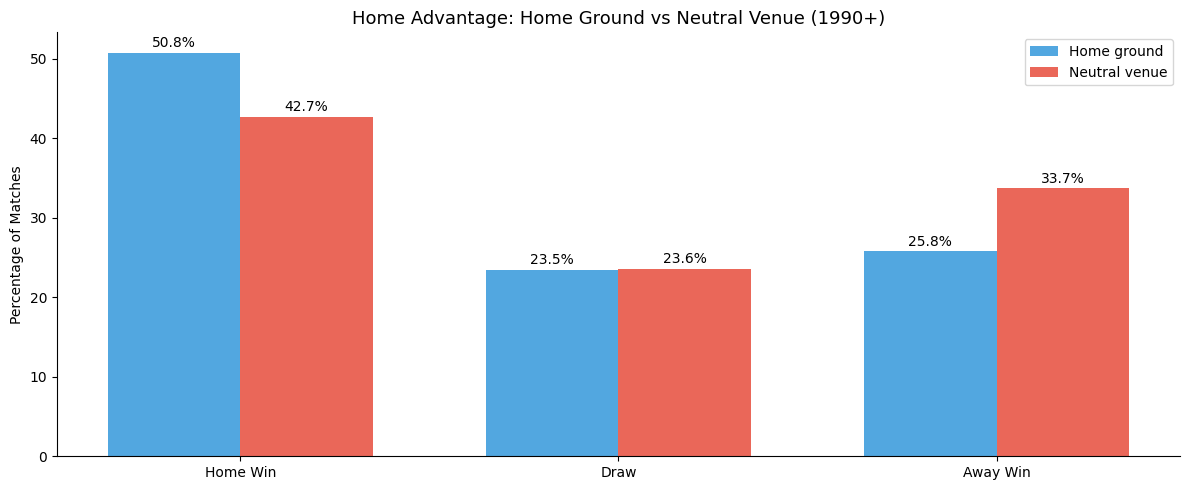

On home ground:   Home wins 50.8%  |  Draws 23.5%  |  Away wins 25.8%
On neutral venue: Home wins 42.7%  |  Draws 23.6%  |  Away wins 33.7%


In [12]:
# Home vs neutral venue comparison
home_games    = modern[modern['neutral'] == False]
neutral_games = modern[modern['neutral'] == True]

def result_pcts(data):
    hw = (data['result'] == 'Home Win').mean() * 100
    d  = (data['result'] == 'Draw').mean()     * 100
    aw = (data['result'] == 'Away Win').mean() * 100
    return hw, d, aw

hw_h, d_h, aw_h = result_pcts(home_games)
hw_n, d_n, aw_n = result_pcts(neutral_games)

categories = ['Home Win', 'Draw', 'Away Win']
home_pcts    = [hw_h, d_h, aw_h]
neutral_pcts = [hw_n, d_n, aw_n]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, home_pcts,    width, label='Home ground',  color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, neutral_pcts, width, label='Neutral venue', color='#e74c3c', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Percentage of Matches')
ax.set_title('Home Advantage: Home Ground vs Neutral Venue (1990+)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/01_home_advantage.png', dpi=150)
plt.show()

print(f'On home ground:   Home wins {hw_h:.1f}%  |  Draws {d_h:.1f}%  |  Away wins {aw_h:.1f}%')
print(f'On neutral venue: Home wins {hw_n:.1f}%  |  Draws {d_n:.1f}%  |  Away wins {aw_n:.1f}%')

## 9. Summary & Key Insights

In [13]:
print('='*60)
print('DATASET SUMMARY')
print('='*60)
print(f'Total matches:            {len(df):,}')
print(f'Date range:               {df["date"].min().year} – {df["date"].max().year}')
print(f'Unique teams:             {len(set(df["home_team"]) | set(df["away_team"]))}')
print()
print('MODERN ERA (1990+)')
print(f'Matches used for model:   {len(modern):,}')
print(f'Avg home goals/match:     {modern["home_score"].mean():.3f}')
print(f'Avg away goals/match:     {modern["away_score"].mean():.3f}')
print()
print('RESULTS SPLIT (1990+)')
for r, pct in (modern['result'].value_counts() / len(modern) * 100).items():
    print(f'  {r:<12}: {pct:.1f}%')
print()
print('KEY INSIGHTS FOR MODELLING:')
print('  1. Goals closely follow a Poisson distribution → Poisson model is valid')
print('  2. Strong home advantage exists (~7pp more home wins at own ground)')
print('  3. Average ~2.7 total goals per match in modern era')
print('  4. Data is clean — minimal missing values')
print('='*60)
print()
print('NEXT: Notebook 02 — Build the Elo Rating System')

DATASET SUMMARY
Total matches:            49,519
Date range:               1872 – 2026
Unique teams:             337

MODERN ERA (1990+)
Matches used for model:   32,401
Avg home goals/match:     1.653
Avg away goals/match:     1.108

RESULTS SPLIT (1990+)
  Home Win    : 48.5%
  Away Win    : 28.0%
  Draw        : 23.5%

KEY INSIGHTS FOR MODELLING:
  1. Goals closely follow a Poisson distribution → Poisson model is valid
  2. Strong home advantage exists (~7pp more home wins at own ground)
  3. Average ~2.7 total goals per match in modern era
  4. Data is clean — minimal missing values

NEXT: Notebook 02 — Build the Elo Rating System
